##### Import statements:

In [73]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [121]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run816', 'iterate_entangler.pickle')
input_dir = os.path.split(input_path)[0]

# Plotting options:
color = 'orange' # Default face color (if color_var is None)
color_var = 'beta_pr' # None | str; variable to plot using color; set to None to make all points same color 
colormap = 'plasma' # Color map to plot color_var in (if color_var is not None)

# Output parameters:
save_output = True
base_dir_name = 'ps_v_pr'

##### Load previously-saved results:

In [122]:
iterate_mdl_results = pickle.load(open(input_path, 'rb'))

##### Find aymptotic participation ratio for all models:

In [123]:
loss_df = iterate_mdl_results['ae_df']
loss_df_ae = loss_df[loss_df.mdl_type=='autoencoder']
max_epoch_df = loss_df_ae[['mdl_id', 'epoch']].groupby('mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
loss_pr_df = pd.merge(loss_df_ae, max_epoch_df, on=['mdl_id', 'epoch'])
#loss_pr_df = pd.DataFrame(loss_pr_df).reset_index().rename()

##### Compute mean asymptotic paralellism score across repeats for each model:

In [124]:
geo_df = iterate_mdl_results['geo_df']

# Find final training epoch for all models:
max_epoch_df = geo_df[['mdl_id', 'epoch']].groupby('mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
max_epoch_df = pd.DataFrame(max_epoch_df)

# Select only results for final training epoch:
geo_df = pd.merge(geo_df, max_epoch_df, on=['mdl_id', 'epoch'])

# Average across repeats:
Mu = geo_df[['mdl_id', 'parallelism']].groupby('mdl_id').mean().reset_index()

# Merge with PR loss:
Mu = pd.merge(Mu, loss_pr_df, on='mdl_id')

##### Scatter data:

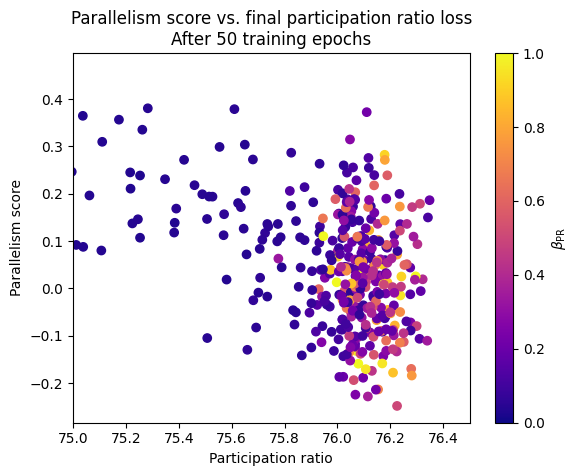

In [131]:
# Define color data:
if color_var is not None:
    C = Mu[color_var]
else:
    C = color
    colormap = None

# Generate scatterplot:
f = plt.figure()
plt.scatter(Mu.loss_pr, Mu.parallelism, c=C, cmap=colormap, label='entangler')

# Axis labels:
plt.ylabel('Parallelism score')
plt.xlabel('Participation ratio')
plt.xlim([69, 76.5])

# Title:
title_base = 'Parallelism score vs. final participation ratio loss'
if len(np.unique(max_epoch_df.epoch)) == 1:
    max_epoch = max_epoch_df.iloc[0].epoch + 1
    max_epoch_str = 'After {} training epochs'.format(max_epoch)
else:
    max_epoch_str = []

title_lines = []
title_lines.append(title_base)
title_lines.append(max_epoch_str)
title = '\n'.join(title_lines)
plt.title(title)

if color_var is not None:
    if color_var == 'beta_pr':
        color_var_str = r'$\beta_{\text{PR}}$'
    else:
        color_var_str = color_var
    plt.colorbar(label=color_var_str)

##### Save output:

In [128]:
if save_output:

    # Create output directory:
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(f)
    file_basename = 'ps_v_pr'
    png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(png_path)
    svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(svg_path)

    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(png_path)
    M.add_output(svg_path)
    metadata_path = os.path.join(curr_output_directory, 'ps_v_pr_metadata.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/iterate_entangler.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/ps_v_pr003/ps_v_pr.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/ps_v_pr003/ps_v_pr.svg...
